In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pylab as pl
import scipy as sp
from scipy import signal
from statsmodels.tsa.stattools import acf
from functools import partial
import math
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

## Data preparation

## TODO: stationary test/more detailed tests on the time series properties (like fat tails, etc.)

In [32]:
sns.set_theme(style="whitegrid")

tickers = ["GC=F", "PAXG-USD", "DX-Y.NYB"]
start_date = "2020-03-20"
end_date = "2026-03-20"

raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  3 of 3 completed


In [123]:
# Clean and Align the Data (The "Inner Join" logic)
# Traditional markets are closed on weekends/holidays, resulting in NaNs.
# Using .dropna() automatically drops the crypto weekend data, aligning everything perfectly.
aligned_data = raw_data.dropna()
aligned_data.columns = ['US Dollar Index', 'Physical Gold', 'PAX Gold']

# Calculate Daily Log-Returns
# Formula: ln(P_t / P_{t-1})
# !!!! attention, we *100 to scale the data

log_returns = np.log(aligned_data / aligned_data.shift(1)).dropna()
gold_array = log_returns['Physical Gold'].values*100
paxg_array = log_returns['PAX Gold'].values*100
usd_array = log_returns['US Dollar Index'].values*100
print(f"Shape of the NumPy arrays: {gold_array.shape} days of trading.")


Shape of the NumPy arrays: (1507,) days of trading.


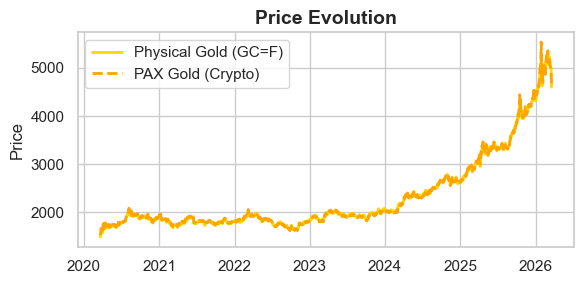

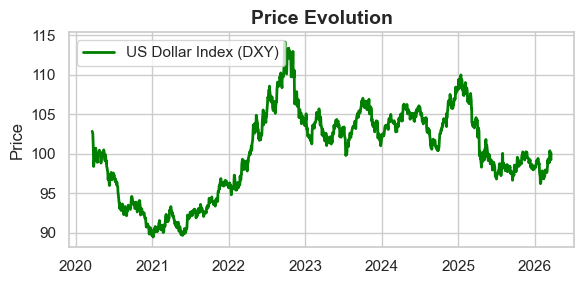

In [169]:
plt.figure(figsize=(6, 3))
plt.plot(aligned_data['Physical Gold'].index, aligned_data['Physical Gold'], label='Physical Gold (GC=F)', color='gold', linewidth=2)
plt.plot(aligned_data.index, aligned_data['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(aligned_data.index, aligned_data['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

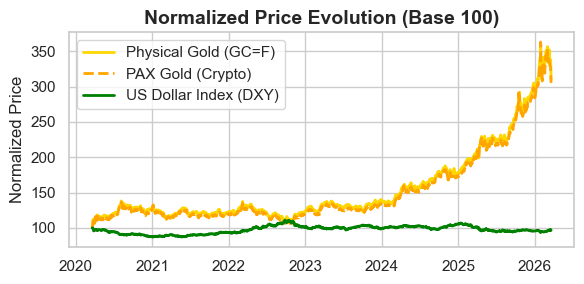

In [168]:
normalized_prices = (aligned_data / aligned_data.iloc[0]) * 100

plt.figure(figsize=(6, 3))
plt.plot(normalized_prices.index, normalized_prices['Physical Gold'], label='Physical Gold (GC=F)', color='gold', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Normalized Price Evolution (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [174]:
print("In terms of daily log-return, we cannot say that \nthe tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.")
print(np.mean(log_returns['Physical Gold']), np.mean(log_returns['PAX Gold']), np.mean(log_returns['US Dollar Index']))
print("For usd, it may proper to manually fix the mean as zero in the GARCH model.")

In terms of daily log-return, we cannot say that 
the tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.
0.0007508078059312596 0.0007407307891193007 -2.3582920971018647e-05
For usd, it may proper to manually fix the mean as zero in the GARCH model.


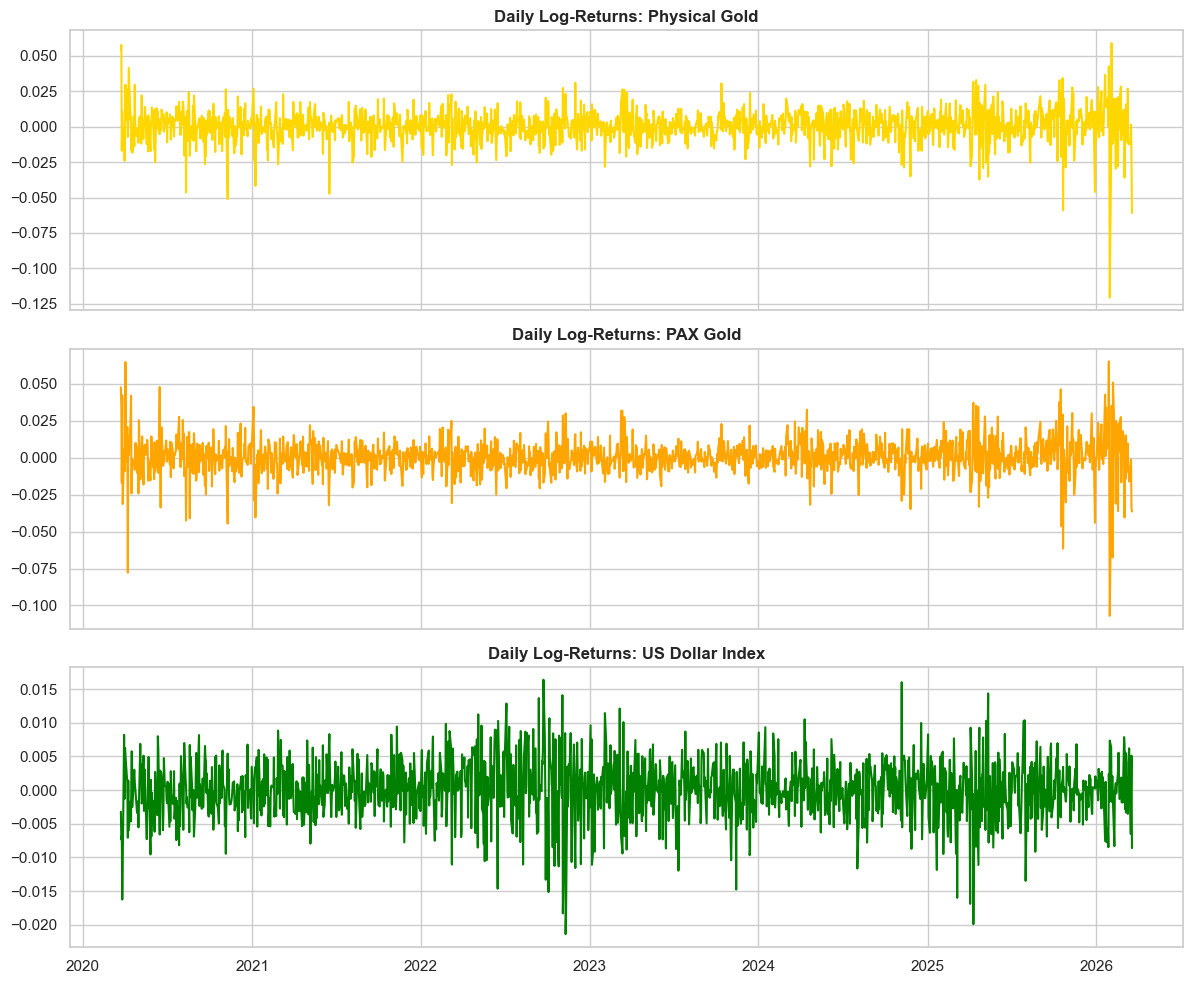

In [178]:
# log return
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(log_returns.index, log_returns['Physical Gold'], color='gold')
axes[0].set_title('Daily Log-Returns: Physical Gold', fontweight='bold')

axes[1].plot(log_returns.index, log_returns['PAX Gold'], color='orange')
axes[1].set_title('Daily Log-Returns: PAX Gold', fontweight='bold')

axes[2].plot(log_returns.index, log_returns['US Dollar Index'], color='green')
axes[2].set_title('Daily Log-Returns: US Dollar Index', fontweight='bold')

plt.tight_layout()
plt.show()

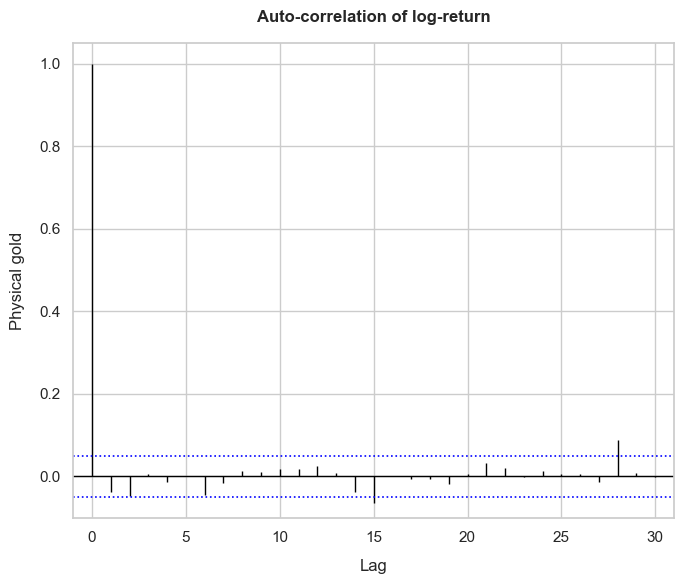

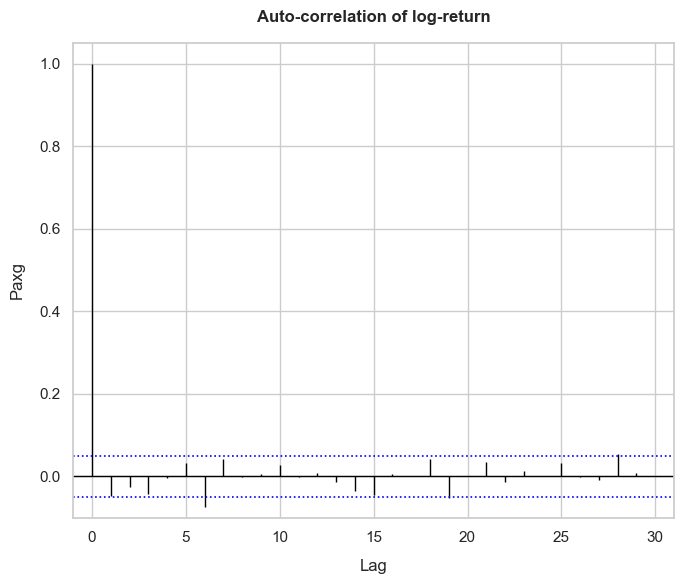

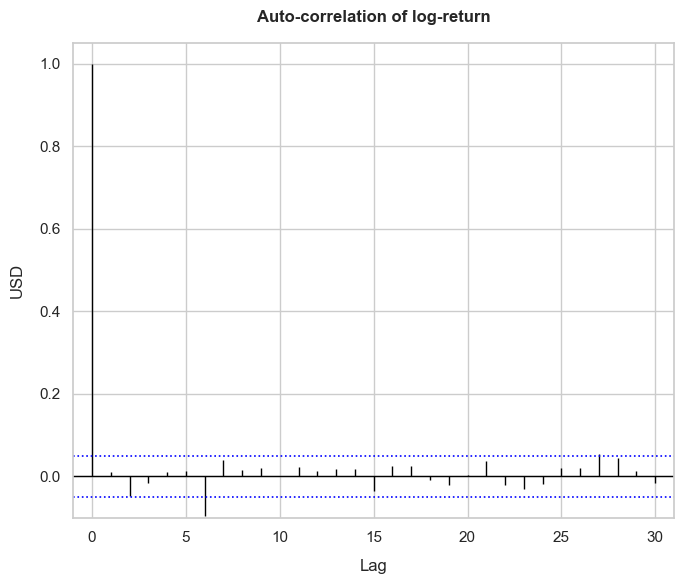

In [127]:
# Fonction d’autocovariance échantillonnale

nlags = 30

# gold 
gold_valeurs_acf = acf(gold_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf = acf(paxg_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(paxg_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf = acf(usd_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(usd_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

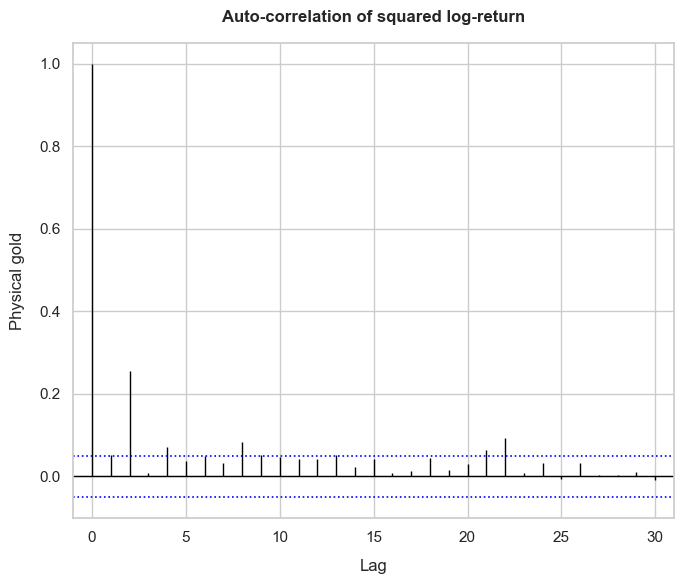

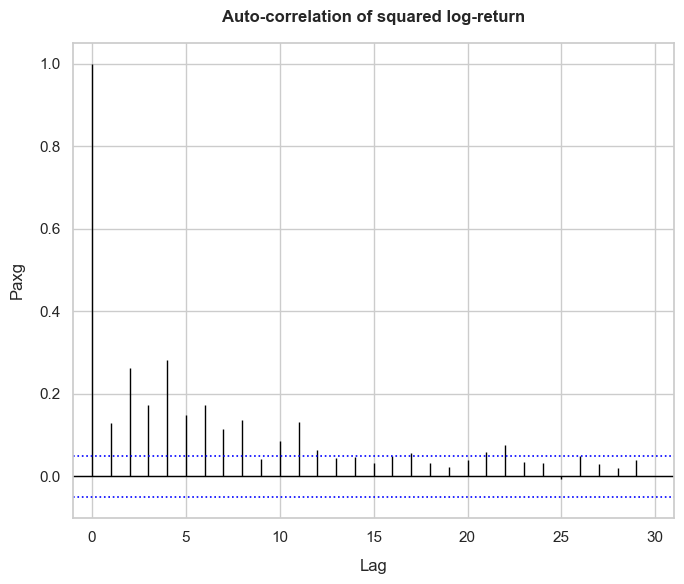

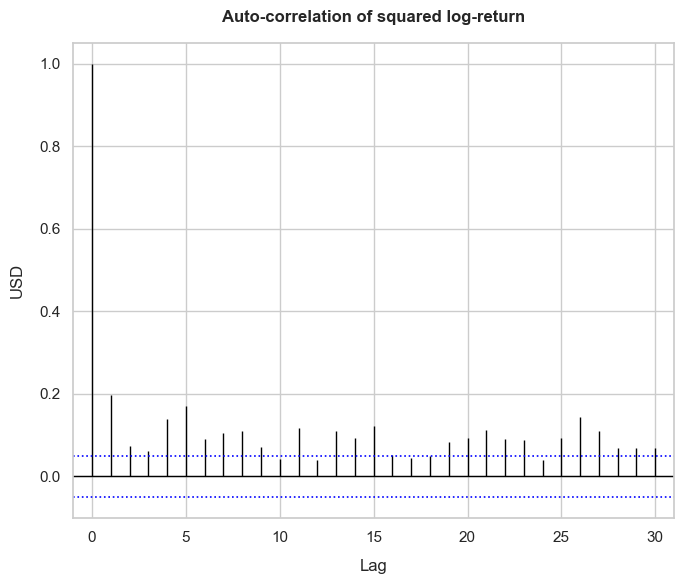

In [128]:
nlags = 30

# gold 
gold_valeurs_acf2 = acf(gold_array**2, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf2 = acf(paxg_array**2, nlags=nlags, fft=True)
plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf2 = acf(usd_array**2, nlags=nlags, fft=True)


plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

- log-return is in general close to a white noise, that is a stationary process at order 2.
- However, there is significant autocorrelation in the time series of squared log-return. This is not compatible with an iid white noise.
- We see volatility clustering in the data: Large values of squared log-return tend to be followed by high values of squared log-return. 
- This is not incompatible with stationary returns, and in particular with a constant variance of the returns.
- This is the reason why we cannot simply use ARMA process, which does not include volatility clustering. 

## GARCH  

### Use package arch for parameters estimation (MLE inside)

Look at https://arch.readthedocs.io/en/latest/univariate/introduction.html for parameter explanations.

In [182]:
from arch import arch_model

In [184]:

gold_garch_model = arch_model(gold_array, vol='GARCH', p=1, q=1, dist='Normal')

# Fit the model using Maximum Likelihood Estimation
# Python will use an optimizer (like 'SLSQP' or 'BFGS') to maximize the likelihood.
gold_garch_results = gold_garch_model.fit(update_freq=20, disp='on')

print(gold_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2230.45
Distribution:                  Normal   AIC:                           4468.91
Method:            Maximum Likelihood   BIC:                           4490.18
                                        No. Observations:                 1507
Date:                Sat, Mar 21 2026   Df Residuals:                     1506
Time:                        17:52:54   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0375  2.831e-02      1.325      0.185 

In [187]:
paxg_garch_model = arch_model(paxg_array, vol='GARCH',p=1, q=1, dist='Normal')

paxg_garch_results = paxg_garch_model.fit(update_freq=20, disp='on')

print(paxg_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2175.20
Distribution:                  Normal   AIC:                           4358.39
Method:            Maximum Likelihood   BIC:                           4379.66
                                        No. Observations:                 1507
Date:                Sat, Mar 21 2026   Df Residuals:                     1506
Time:                        17:54:19   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0467  2.426e-02      1.925  5.424e-02 

In [ ]:
usd_garch_model = arch_model(usd_array, vol='GARCH',mean='Zero',p=1, q=1, dist='Normal')

usd_garch_results = usd_garch_model.fit(update_freq=20, disp='on')

print(usd_garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -831.366
Distribution:                  Normal   AIC:                           1668.73
Method:            Maximum Likelihood   BIC:                           1684.69
                                        No. Observations:                 1507
Date:                Sat, Mar 21 2026   Df Residuals:                     1507
Time:                        17:53:07   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.6301e-03  1.241e-03      2.119  3.408e-02 [1.

**Attention:** the estimated mu for gold and paxg has a confidence interval quite large, which includes 0... 
And we have forced mean = zero for usd.

### TODO: MMG method for parameter estimation